## Tool definition

### Setup

In [58]:
# --- Env & Dev Imports -- START
from dotenv import load_dotenv
load_dotenv()
from typing import Union, Dict, Any
from tavily import TavilyClient
# --- Env & Dev Imports -- END

# --- Data Science and Agentic Imports -- START -- #
from langchain.tools import tool
import pandas as pd
from torch import TensorType
from pyspark import sql as psql
from matplotlib import pyplot as plt
from pandas import read_excel
import numpy as np
# --- Data Science and Agentic Imports -- END -- #

# Variables carrying information relevat to tools decorator
data_path:str = r"../../datasets/GDT_Tables_Q126_EN.xlsx"
description:str = "Display both, the histogram depicting the linearized data and its associated raw counterpart in a chart form" 
AnyArgumentType = Union[pd.DataFrame, TensorType, psql.DataFrame, str]
model_code, model_provider = "gemini-3.5-flash-lite", "google_genai:"
print(model_provider+model_code)

google_genai:gemini-3.5-flash-lite


### Tooling basics

In [ ]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

In [ ]:
tool1.invoke({"x": 467})

## Adding tools to agents

<class 'str'>


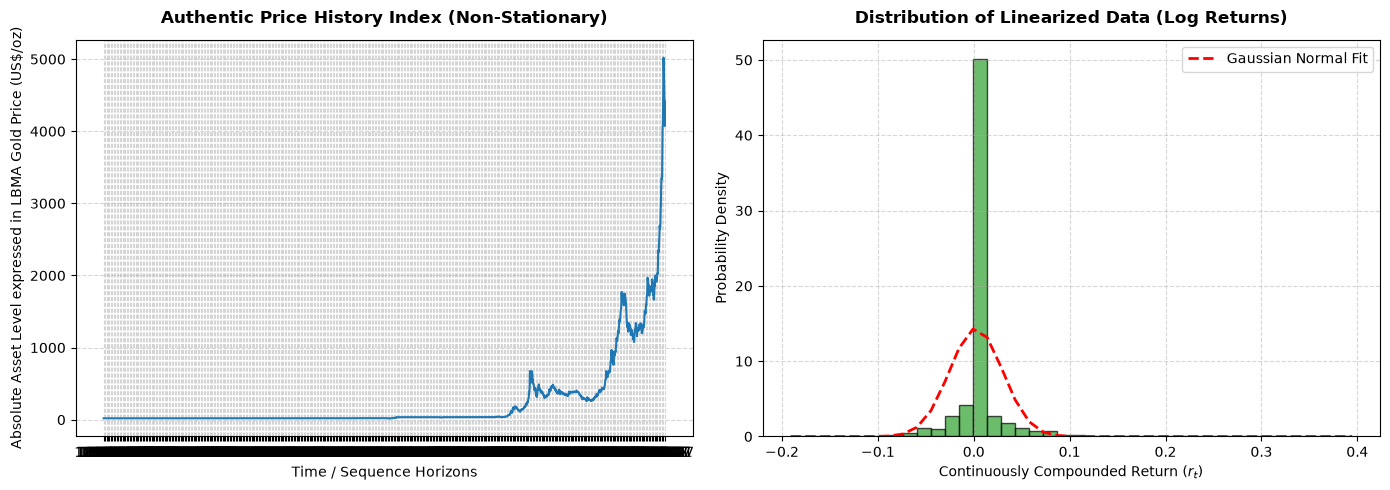

In [ ]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage, AIMessage
gold_data_lp:str = "https://datahub.io/core/gold-prices"
gold_downloadable:str = "https://datahub.io/core/gold-prices/_r/-/data/monthly.csv"

human_prompt = HumanMessage(content="I need to visualize the gold price evolution and its linearized counterpart. " \
f"Trigger the display_dist tool by passing it this exact URL as a string: {gold_downloadable}. Do not attempt to parse, read, or format the data yourself")
sys_prompt = SystemMessage(content="You are an extremely experienced economist, very knowledgable about asset return calculations.")

gemini_agent_instance = create_agent(model=model_provider+model_code, system_prompt=sys_prompt, tools=[tool1, tool2])
response = gemini_agent_instance.invoke({"messages":human_prompt})

In [52]:
print(response['messages'][-1].content)
print(response['messages'][1].tool_calls)
from pprint import pprint
pprint(response['messages'])

[{'type': 'text', 'text': '```json\n{\n  "1833-01": 18.930,\n  "1833-02": 18.930,\n  "1833-03": 18.930,\n  "1833-04": 18.930,\n  "1833-05": 18.930,\n  "1833-06": 18.930,\n  "1833-07": 18.930,\n  "1833-08": 18.930,\n  "1833-09": 18.930,\n  "1833-10": 18.930,\n  "1833-11": 18.930,\n  "1833-12": 18.930\n}\n```', 'extras': {'signature': 'El4KXAFpFH0TTKW8Z6OmQi9o32ApB/ezrDi4+ohyCR/D7vPgXI+VP6ZSvWVI0dYewtRu98ciTaDQq0o3NdeRGDjC9IGdaA/WFHyvp68lc1EcbqSVXdccF2OCZ0aEl+8+'}}]
[{'name': 'web_search', 'args': {'query': 'https datahub io core gold prices monthly csv'}, 'id': 'call_369146', 'type': 'tool_call'}]
[HumanMessage(content='Please retrieve the monthly gold price data from this URL: https://datahub.io/core/gold-prices. Extract the fiscal time periods and their corresponding prices. To visualize this, invoke one of the tools made available to you. You must format your input argument strictly as a single JSON dictionary where the keys are the time periods (as strings) and the values are the nu

In [ ]:
from langchain.messages import HumanMessage

question = HumanMessage(content="What is the square root of 467?")

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

In [ ]:
from pprint import pprint

pprint(response['messages'])

In [ ]:
print(response["messages"][1].tool_calls)

## Enhanced tools (e.g., built in web searching APIs such as `Tavily`)

In [43]:
@tool("web_search", description="Tool dedicated to web searching related acitivities")
def tool2(query:str)->Dict[str, any]:
    """
    Searches the web for information
    """
    tavily_client = TavilyClient()
    return tavily_client.search(query=query)

tool2.invoke({'query': 'Could you find the Supply & Demand Gold dataset and tabulate the figures relevant to its price evolution across the last 30 years?'})

{'query': 'Could you find the Supply & Demand Gold dataset and tabulate the figures relevant to its price evolution across the last 30 years?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.gold.org/goldhub/research/gold-demand-trends',
   'title': 'Gold Demand Trends',
   'content': 'US gold demand more than doubled to 679t in 2025, driven almost entirely by strong investment demand in physically-gold‑backed ETFs. US‑listed ETFs added 437t of demand,  pushing holdings to a record 2,019t (US$280bn AUM). Jewellery, technology, and bar‑and‑coin demand softened amid historically high gold prices, even as value‑based purchasing – particularly for jewellery – held relatively firm. Geopolitical uncertainty, rate expectations, and a weaker dollar supported strong investor appetite [...] ### Gold Demand Trends: Q1 2026\n\nGold demand saw a modest y/y increase in Q1 to 1,231t, while value surged to a record US$193bn. Bar and coin investment drov

# User case formulation
The consequence-free and well thought-through offloading attempt, which translates into partly automatizing data analysis remains central to this project.
Solid conclusions were drawn from the previous discussion series so the necessary data analysis consensus hinges on that. This consensus should help us bring
in the existence a protocol, containing indispensable and common data analysis steps to all the projects.

1. Draw the distribution of the target variable; 
2. Create a correlation matrix

In [ ]:
# 1. Display the distribution of the selected variable using a histogram, accompanied by a legend that indicates the variable being represented.
# Tool itself
@tool("display_dist", description=description)
def tool1(target_variable: AnyArgumentType) -> None:
    """
    Generates a two-windowed plot where:
    - The left side depicts the authentic historical price index trajectory.
    - The right side depicts the histogram (PDF) of the linearized log returns.
    """
    # 0. Delegate routing layer
    if isinstance(target_variable, str):
        df = pd.read_csv(target_variable)
        df.set_index('Date', inplace=True)
        s = pd.to_numeric(df['Price'], errors='coerce').dropna()

    # 1. Force the target variable into a clean pandas Series framework
    elif isinstance(target_variable, (pd.Series, pd.DataFrame)):
        s = pd.Series(target_variable.squeeze())
    else:
        print(type(target_variable))
        s = target_variable

    # 2. Linearization transformation: Compute continuously compounded log returns
    # This stabilizes the mean and changes explosive trends into time-additive variations
    log_returns = np.log(s / s.shift(1)).dropna()

    # 3. Setup the dual-window plot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left Window: Authentic Price History Chart ---
    # Captures the raw asset trajectory over its temporal index
    time_axis = s.index if hasattr(s, 'index') else range(len(s))
    axes[0].plot(time_axis, s.values, color='#1f77b4', linewidth=1.5, label='Price Index')
    axes[0].set_title("Authentic Price History Index (Non-Stationary)", fontsize=12, fontweight='bold', pad=12)
    axes[0].set_xlabel("Time / Sequence Horizons", fontsize=10)
    axes[0].set_ylabel("Absolute Asset Level expressed in LBMA Gold Price (US$/oz)", fontsize=10)
    axes[0].set_xticks(time_axis[::6])
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # --- Right Window: Histogram of Linearized Data ---
    # Maps out the statistical distribution. Setting density=True formats it as a proper PDF
    _, bins, _ = axes[1].hist(
        log_returns.values, bins=40, density=True, color='#2ca02c', edgecolor='black', alpha=0.7
    )
    axes[1].set_title("Distribution of Linearized Data (Log Returns)", fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel("Continuously Compounded Return ($r_t$)", fontsize=10)
    axes[1].set_ylabel("Probability Density", fontsize=10)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # 4. Optional Stylized Overlap: Plot a Gaussian curve using sample mean/volatility 
    # to demonstrate empirical properties like fat tails or skewness
    mu, sigma = log_returns.mean(), log_returns.std()
    theoretical_normal = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((bins - mu) ** 2) / (2 * sigma ** 2))
    axes[1].plot(bins, theoretical_normal, color='red', linestyle='--', linewidth=2, label=f'Gaussian Normal Fit')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()
    
    return None


             price
3                 
Q1'10  1109.115079
Q2'10  1196.741803
Q3'10  1226.750000
Q4'10  1366.782258
Q1'11  1386.265873
...            ...
Q1'25  2859.619048
Q2'25  3280.352459
Q3'25  3456.543846
Q4'25  4135.235484
Q1'26  4872.889683

[65 rows x 1 columns]
<class 'pandas.DataFrame'>


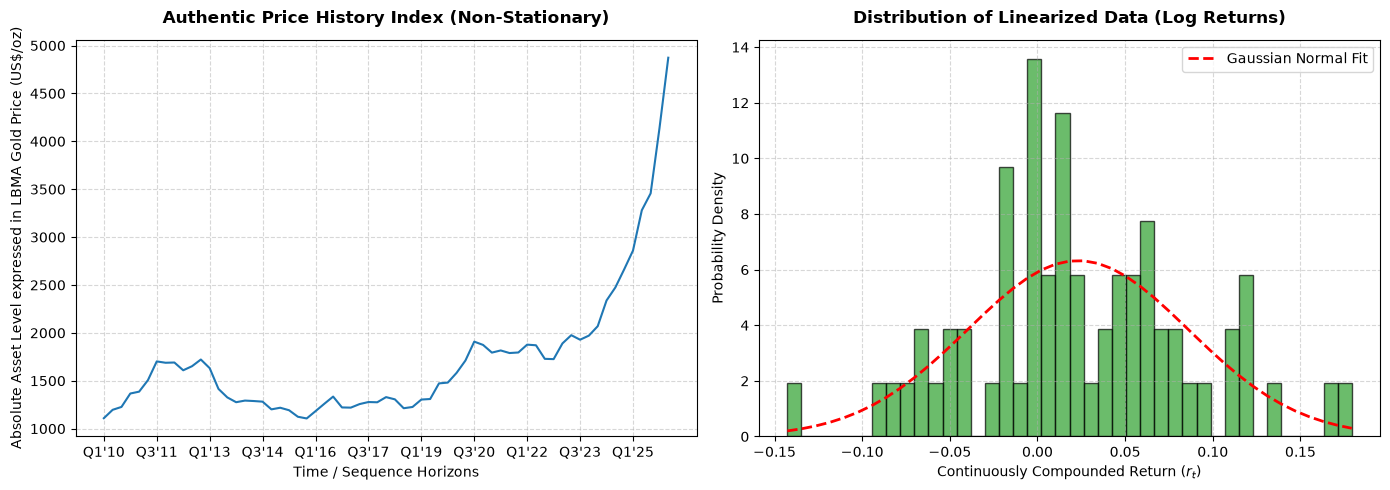

In [94]:
# 2. Crafting the dataset and testing whether it works or not
dataset = read_excel(io=data_path, sheet_name='Gold Balance', engine='openpyxl')
price = dataset.iloc[26, 22:-2]
timestamp = dataset.iloc[3,22:-2]
target_var = pd.DataFrame({'price':price})
target_var.index = timestamp
target_var['price'] = pd.to_numeric(target_var['price'], errors='coerce')

# 3. Test the previously created tool
print(target_var)
tool1.invoke({'target_variable':target_var})